In [ ]:
pip install tensorflow

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.datasets import mnist
(x_train, _), (_, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Load and preprocess data
# ==============================
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train / 127.5 - 1.0  # Normalize to [-1, 1]
x_train = x_train.reshape(-1, 28, 28, 1)
print(x_train.shape)

BUFFER_SIZE = 60000
BATCH_SIZE = 256
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

(60000, 28, 28, 1)


In [ ]:
# ==============================
# Generator
# ==============================
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Reshape((7, 7, 256)),
    tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ==============================
# Discriminator
# ==============================
discriminator = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ==============================
# Loss and Optimizers
# ==============================
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# ==============================
# Loss functions
# ==============================
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

Epoch 1, Gen Loss: 0.7213, Disc Loss: 1.3517
Real Output Mean: 0.5234, Fake Output Mean: 0.4893


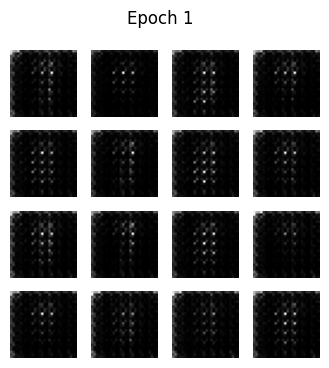

Epoch 2, Gen Loss: 0.8426, Disc Loss: 1.2040
Real Output Mean: 0.5969, Fake Output Mean: 0.4473


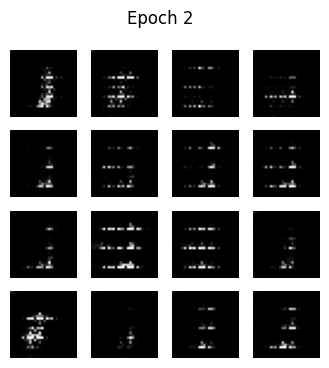

Epoch 3, Gen Loss: 0.7428, Disc Loss: 1.3922
Real Output Mean: 0.5864, Fake Output Mean: 0.5155


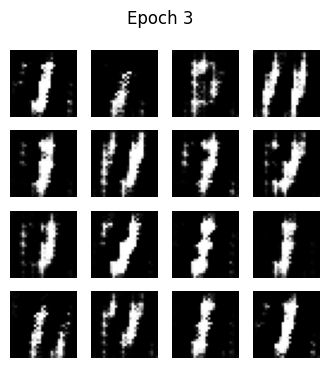

Epoch 4, Gen Loss: 0.7914, Disc Loss: 1.3482
Real Output Mean: 0.5558, Fake Output Mean: 0.4789


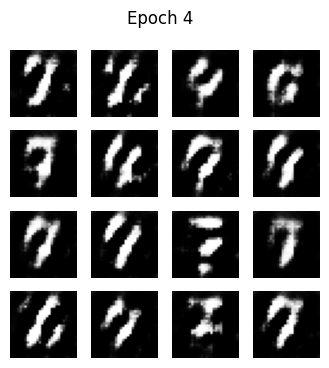

Epoch 5, Gen Loss: 0.8068, Disc Loss: 1.5209
Real Output Mean: 0.4921, Fake Output Mean: 0.4829


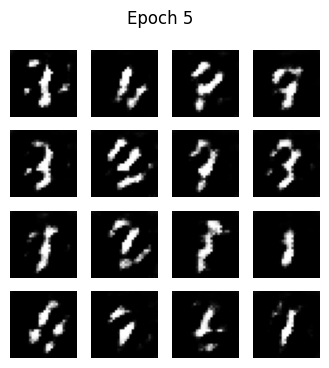

Epoch 6, Gen Loss: 0.9471, Disc Loss: 1.3811
Real Output Mean: 0.5286, Fake Output Mean: 0.4297


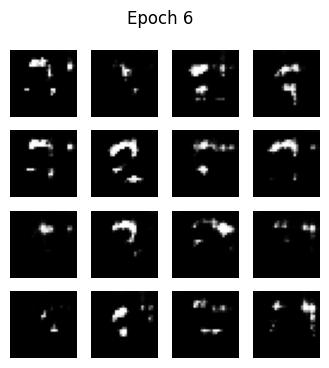

Epoch 7, Gen Loss: 1.0700, Disc Loss: 1.0745
Real Output Mean: 0.5641, Fake Output Mean: 0.3597


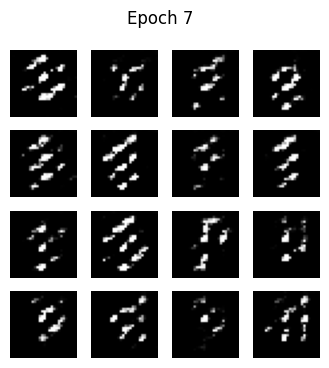

Epoch 8, Gen Loss: 1.0305, Disc Loss: 1.1566
Real Output Mean: 0.5935, Fake Output Mean: 0.3988


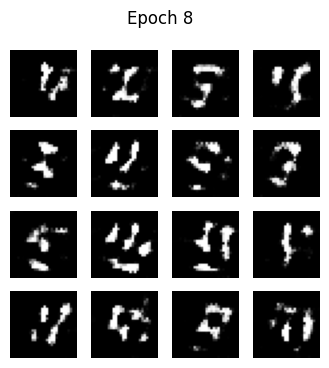

Epoch 9, Gen Loss: 1.0520, Disc Loss: 0.9788
Real Output Mean: 0.6411, Fake Output Mean: 0.3715


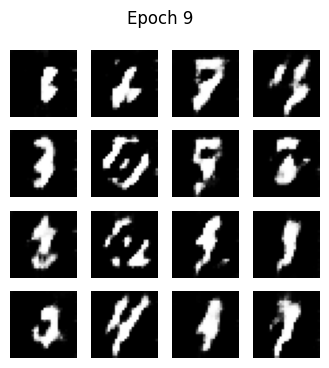

Epoch 10, Gen Loss: 0.9991, Disc Loss: 1.1023
Real Output Mean: 0.6097, Fake Output Mean: 0.3965


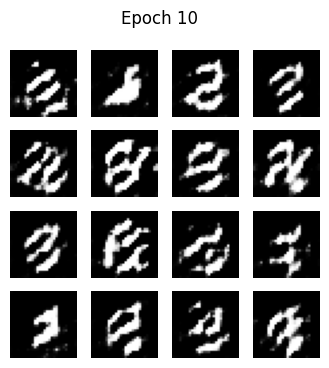

Epoch 11, Gen Loss: 1.0615, Disc Loss: 1.1339
Real Output Mean: 0.5710, Fake Output Mean: 0.3732


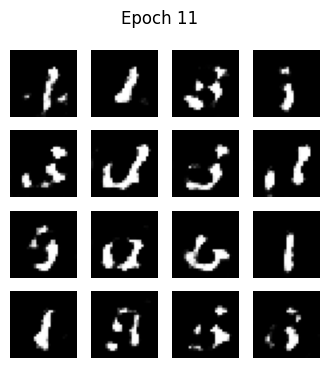

Epoch 12, Gen Loss: 1.1230, Disc Loss: 0.9238
Real Output Mean: 0.6821, Fake Output Mean: 0.3573


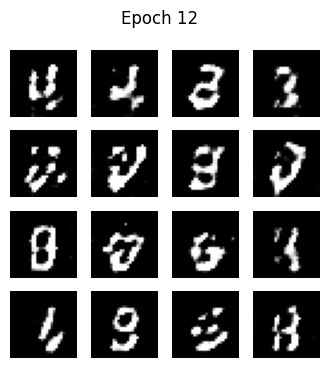

Epoch 13, Gen Loss: 1.0224, Disc Loss: 1.1302
Real Output Mean: 0.6080, Fake Output Mean: 0.4019


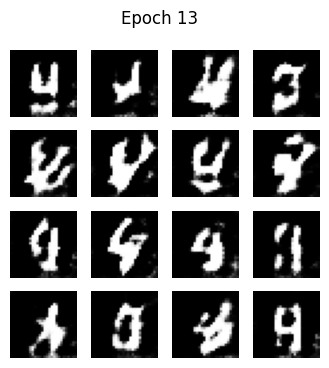

Epoch 14, Gen Loss: 1.3223, Disc Loss: 1.0626
Real Output Mean: 0.6426, Fake Output Mean: 0.3292


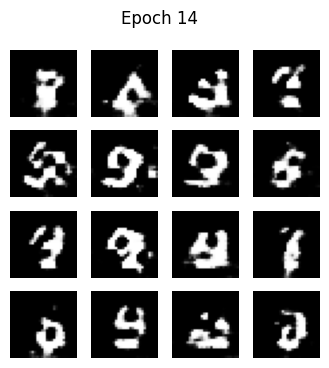

Epoch 15, Gen Loss: 0.9316, Disc Loss: 1.3728
Real Output Mean: 0.5806, Fake Output Mean: 0.4516


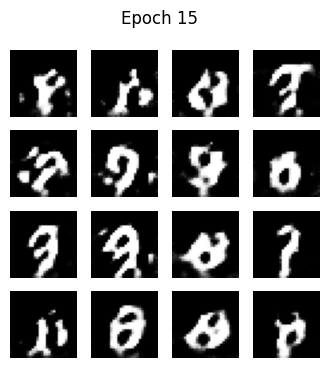

Epoch 16, Gen Loss: 0.8710, Disc Loss: 1.3195
Real Output Mean: 0.6002, Fake Output Mean: 0.4652


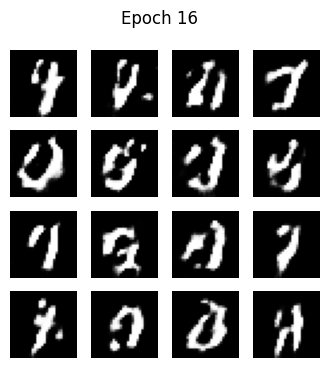

Epoch 17, Gen Loss: 1.2276, Disc Loss: 1.0574
Real Output Mean: 0.6356, Fake Output Mean: 0.3474


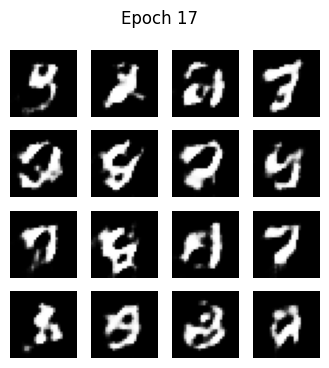

Epoch 18, Gen Loss: 1.2761, Disc Loss: 1.1561
Real Output Mean: 0.5705, Fake Output Mean: 0.3302


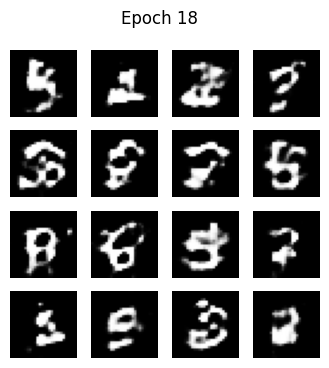

Epoch 19, Gen Loss: 1.2182, Disc Loss: 1.0634
Real Output Mean: 0.6940, Fake Output Mean: 0.3704


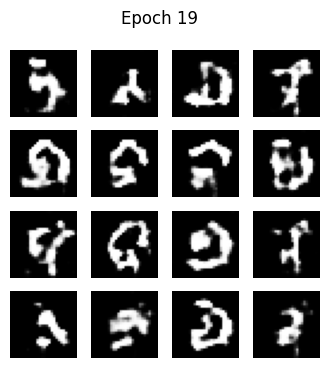

Epoch 20, Gen Loss: 1.2758, Disc Loss: 0.7748
Real Output Mean: 0.7572, Fake Output Mean: 0.3356


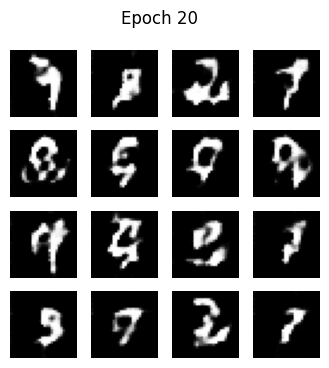

Epoch 21, Gen Loss: 1.3550, Disc Loss: 0.9164
Real Output Mean: 0.6777, Fake Output Mean: 0.3191


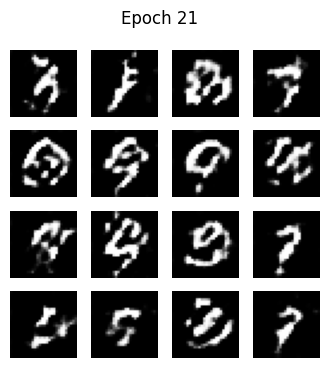

Epoch 22, Gen Loss: 1.3296, Disc Loss: 0.9777
Real Output Mean: 0.6739, Fake Output Mean: 0.3294


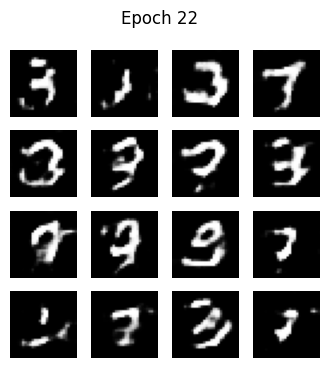

Epoch 23, Gen Loss: 1.3523, Disc Loss: 0.8844
Real Output Mean: 0.7057, Fake Output Mean: 0.3291


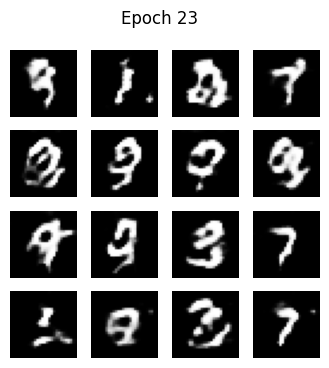

Epoch 24, Gen Loss: 1.2384, Disc Loss: 1.1229
Real Output Mean: 0.5901, Fake Output Mean: 0.3427


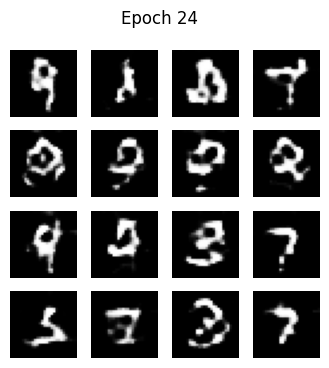

Epoch 25, Gen Loss: 1.4573, Disc Loss: 0.8872
Real Output Mean: 0.6969, Fake Output Mean: 0.3205


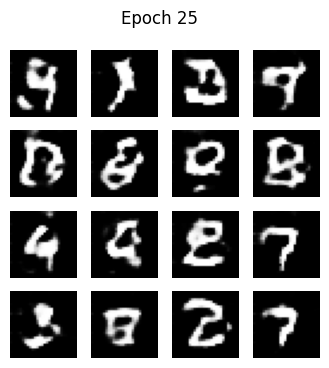

Epoch 26, Gen Loss: 1.2470, Disc Loss: 1.1293
Real Output Mean: 0.6320, Fake Output Mean: 0.3596


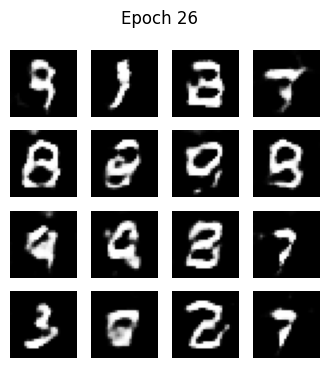

Epoch 27, Gen Loss: 1.1878, Disc Loss: 0.9864
Real Output Mean: 0.6757, Fake Output Mean: 0.3630


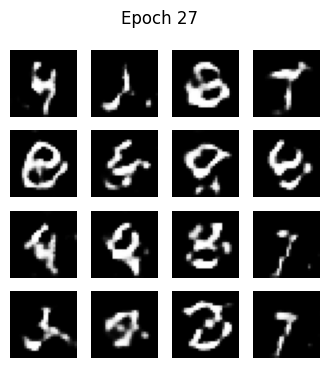

Epoch 28, Gen Loss: 1.0631, Disc Loss: 1.0694
Real Output Mean: 0.6739, Fake Output Mean: 0.4025


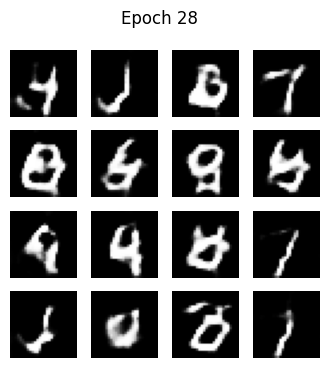

Epoch 29, Gen Loss: 0.9286, Disc Loss: 1.3889
Real Output Mean: 0.5506, Fake Output Mean: 0.4466


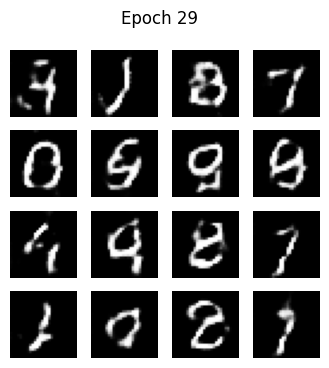

Epoch 30, Gen Loss: 0.8490, Disc Loss: 1.2547
Real Output Mean: 0.6517, Fake Output Mean: 0.4787


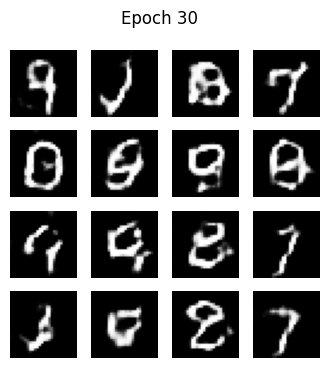

In [ ]:
#@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss, real_output, fake_output

# Training loop
# ==============================
EPOCHS = 30
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')  # Convert from [-1,1] to [0,1]
        plt.axis('off')

    plt.suptitle(f'Epoch {epoch}', fontsize=12)
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            gen_loss, disc_loss, real_output, fake_output = train_step(image_batch)

        # Print discriminator's predictions on real and fake images
        print(f'Epoch {epoch+1}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}')
        print(f'Real Output Mean: {tf.reduce_mean(real_output):.4f}, Fake Output Mean: {tf.reduce_mean(fake_output):.4f}')

        generate_and_save_images(generator, epoch + 1, seed)

# Run training
# ==============================
train(train_dataset, EPOCHS)